# PART 1: Import packages and set up FRED

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import time
from dotenv import dotenv_values
from fredapi import Fred

# Setting up pyplot formatting
plt.style.use('fivethirtyeight')
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

# The FRED API key is in a .env file, which isn't on Github
# Replace the value of the fred_key variable with your own key
fred_key = dotenv_values('.env')['FRED_API_KEY']
fred = Fred(api_key=fred_key)

# PART 2: Pull and plot S&P 500 data

<Axes: title={'center': 'S&P 500'}>

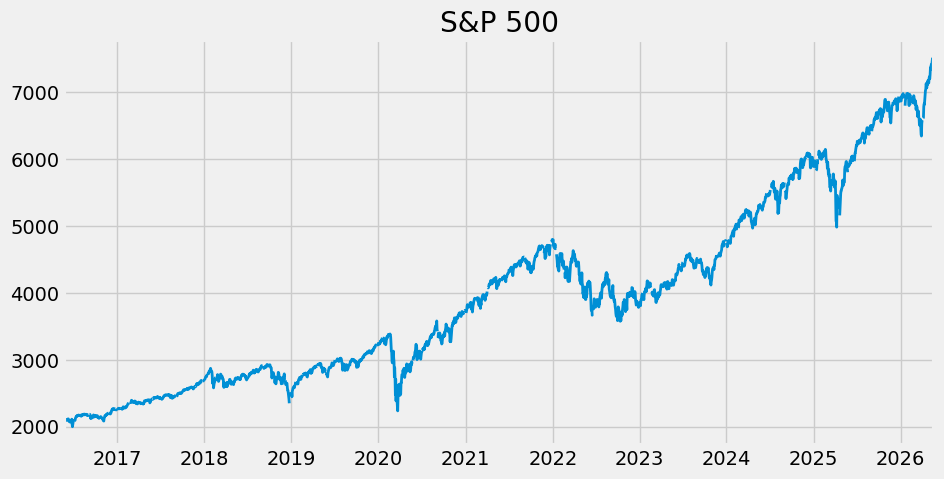

In [2]:
# Creates a Pandas series with the S&P 500 value each day for the past 10 years
sp500 = fred.get_series('SP500')
sp500.plot(figsize=(10,5), title='S&P 500', lw=2)

# PART 3: Pull and plot state unemployment data

Note: the graph in this step cannot be shown in GitHub's preview mode.

In [ ]:
# This dictionary is here to loop through all US states, and rename
# columns to use the full state names
us_states = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "DC": "District of Columbia",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming",
}

# List of DataFrames for each state's unemployment data
all_results = []
for state in list(us_states.keys()):
    # The series code for each state's unemployment data is: abbreviation + "UR"
    results = fred.get_series(state+'UR')
    results = results.to_frame(name=us_states[state])
    all_results.append(results)
    time.sleep(0.1) # Pause to avoid getting blocked

# Combine uneployment data of all states into one DataFrame
uemp_states = pd.concat(all_results, axis=1)

# Drop all null values from the frame, then plot all states' unemployment data
uemp_states = uemp_states.dropna()
px.line(uemp_states)


# Part 4: Pull and Plot May 2020 unemployment data per state

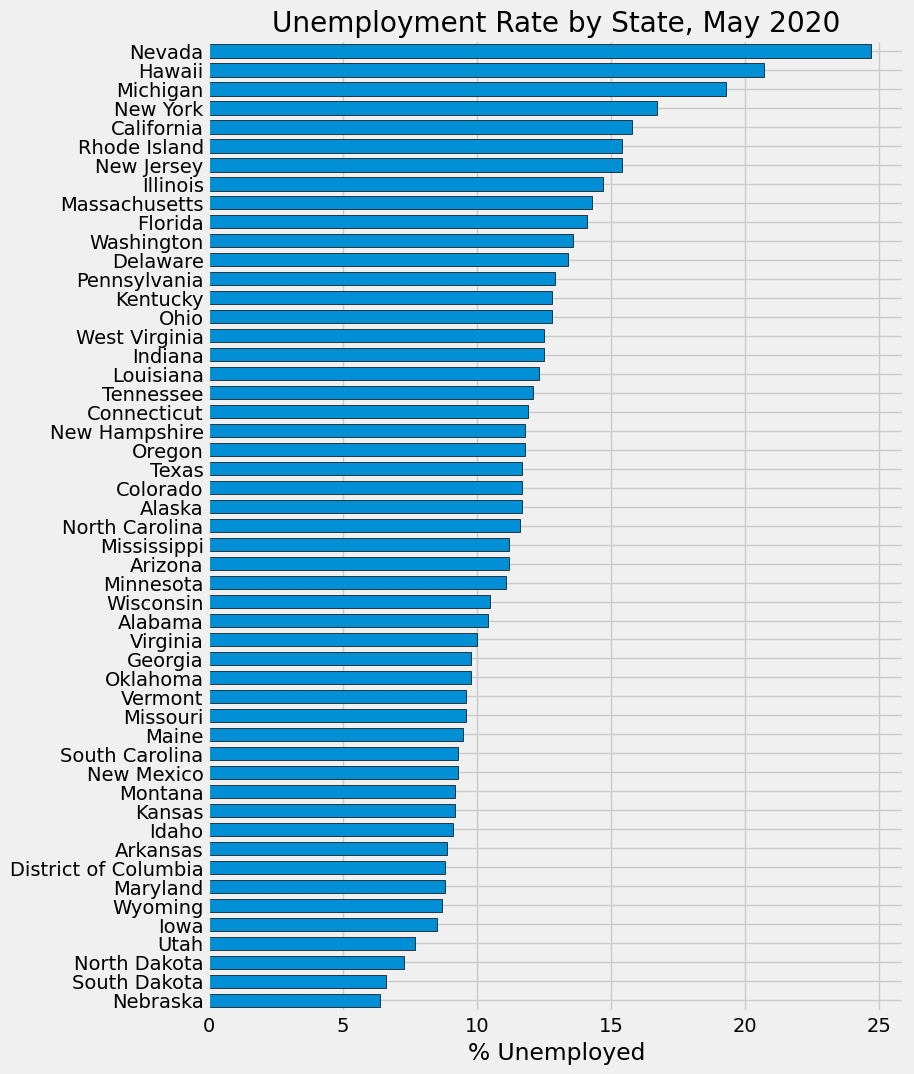

In [4]:
# Create a bar graph to show each state's unemployment rate on 5/1/2020
ax = uemp_states.loc[uemp_states.index == '2020-05-01'].T \
    .sort_values('2020-05-01') \
    .plot(kind='barh', figsize=(8, 12), width=0.7, edgecolor='black',
          title='Unemployment Rate by State, May 2020')
ax.legend().remove()
ax.set_xlabel('% Unemployed')
plt.show()

# Part 5: Pull participation rate data per state

In [5]:
part_df = fred.search('participation rate state', filter=('frequency','Monthly'))
part_df = part_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')

# This ends up pulling participation rate data not just
# for states, but other demographics.

part_id_to_state = part_df['title'].str.replace('Labor Force Participation Rate for ','').to_dict()

all_results = []

for myid in part_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(name=myid)
    all_results.append(results)
    time.sleep(0.1) # Pause to avoid getting blocked
part_states = pd.concat(all_results, axis=1)

# Rename columns in part_states to use just the state names, for consistency with uemp_states
part_states.columns = [part_id_to_state[c] for c in part_states.columns]

# Part 6: Plot unemployemt vs. participation per state

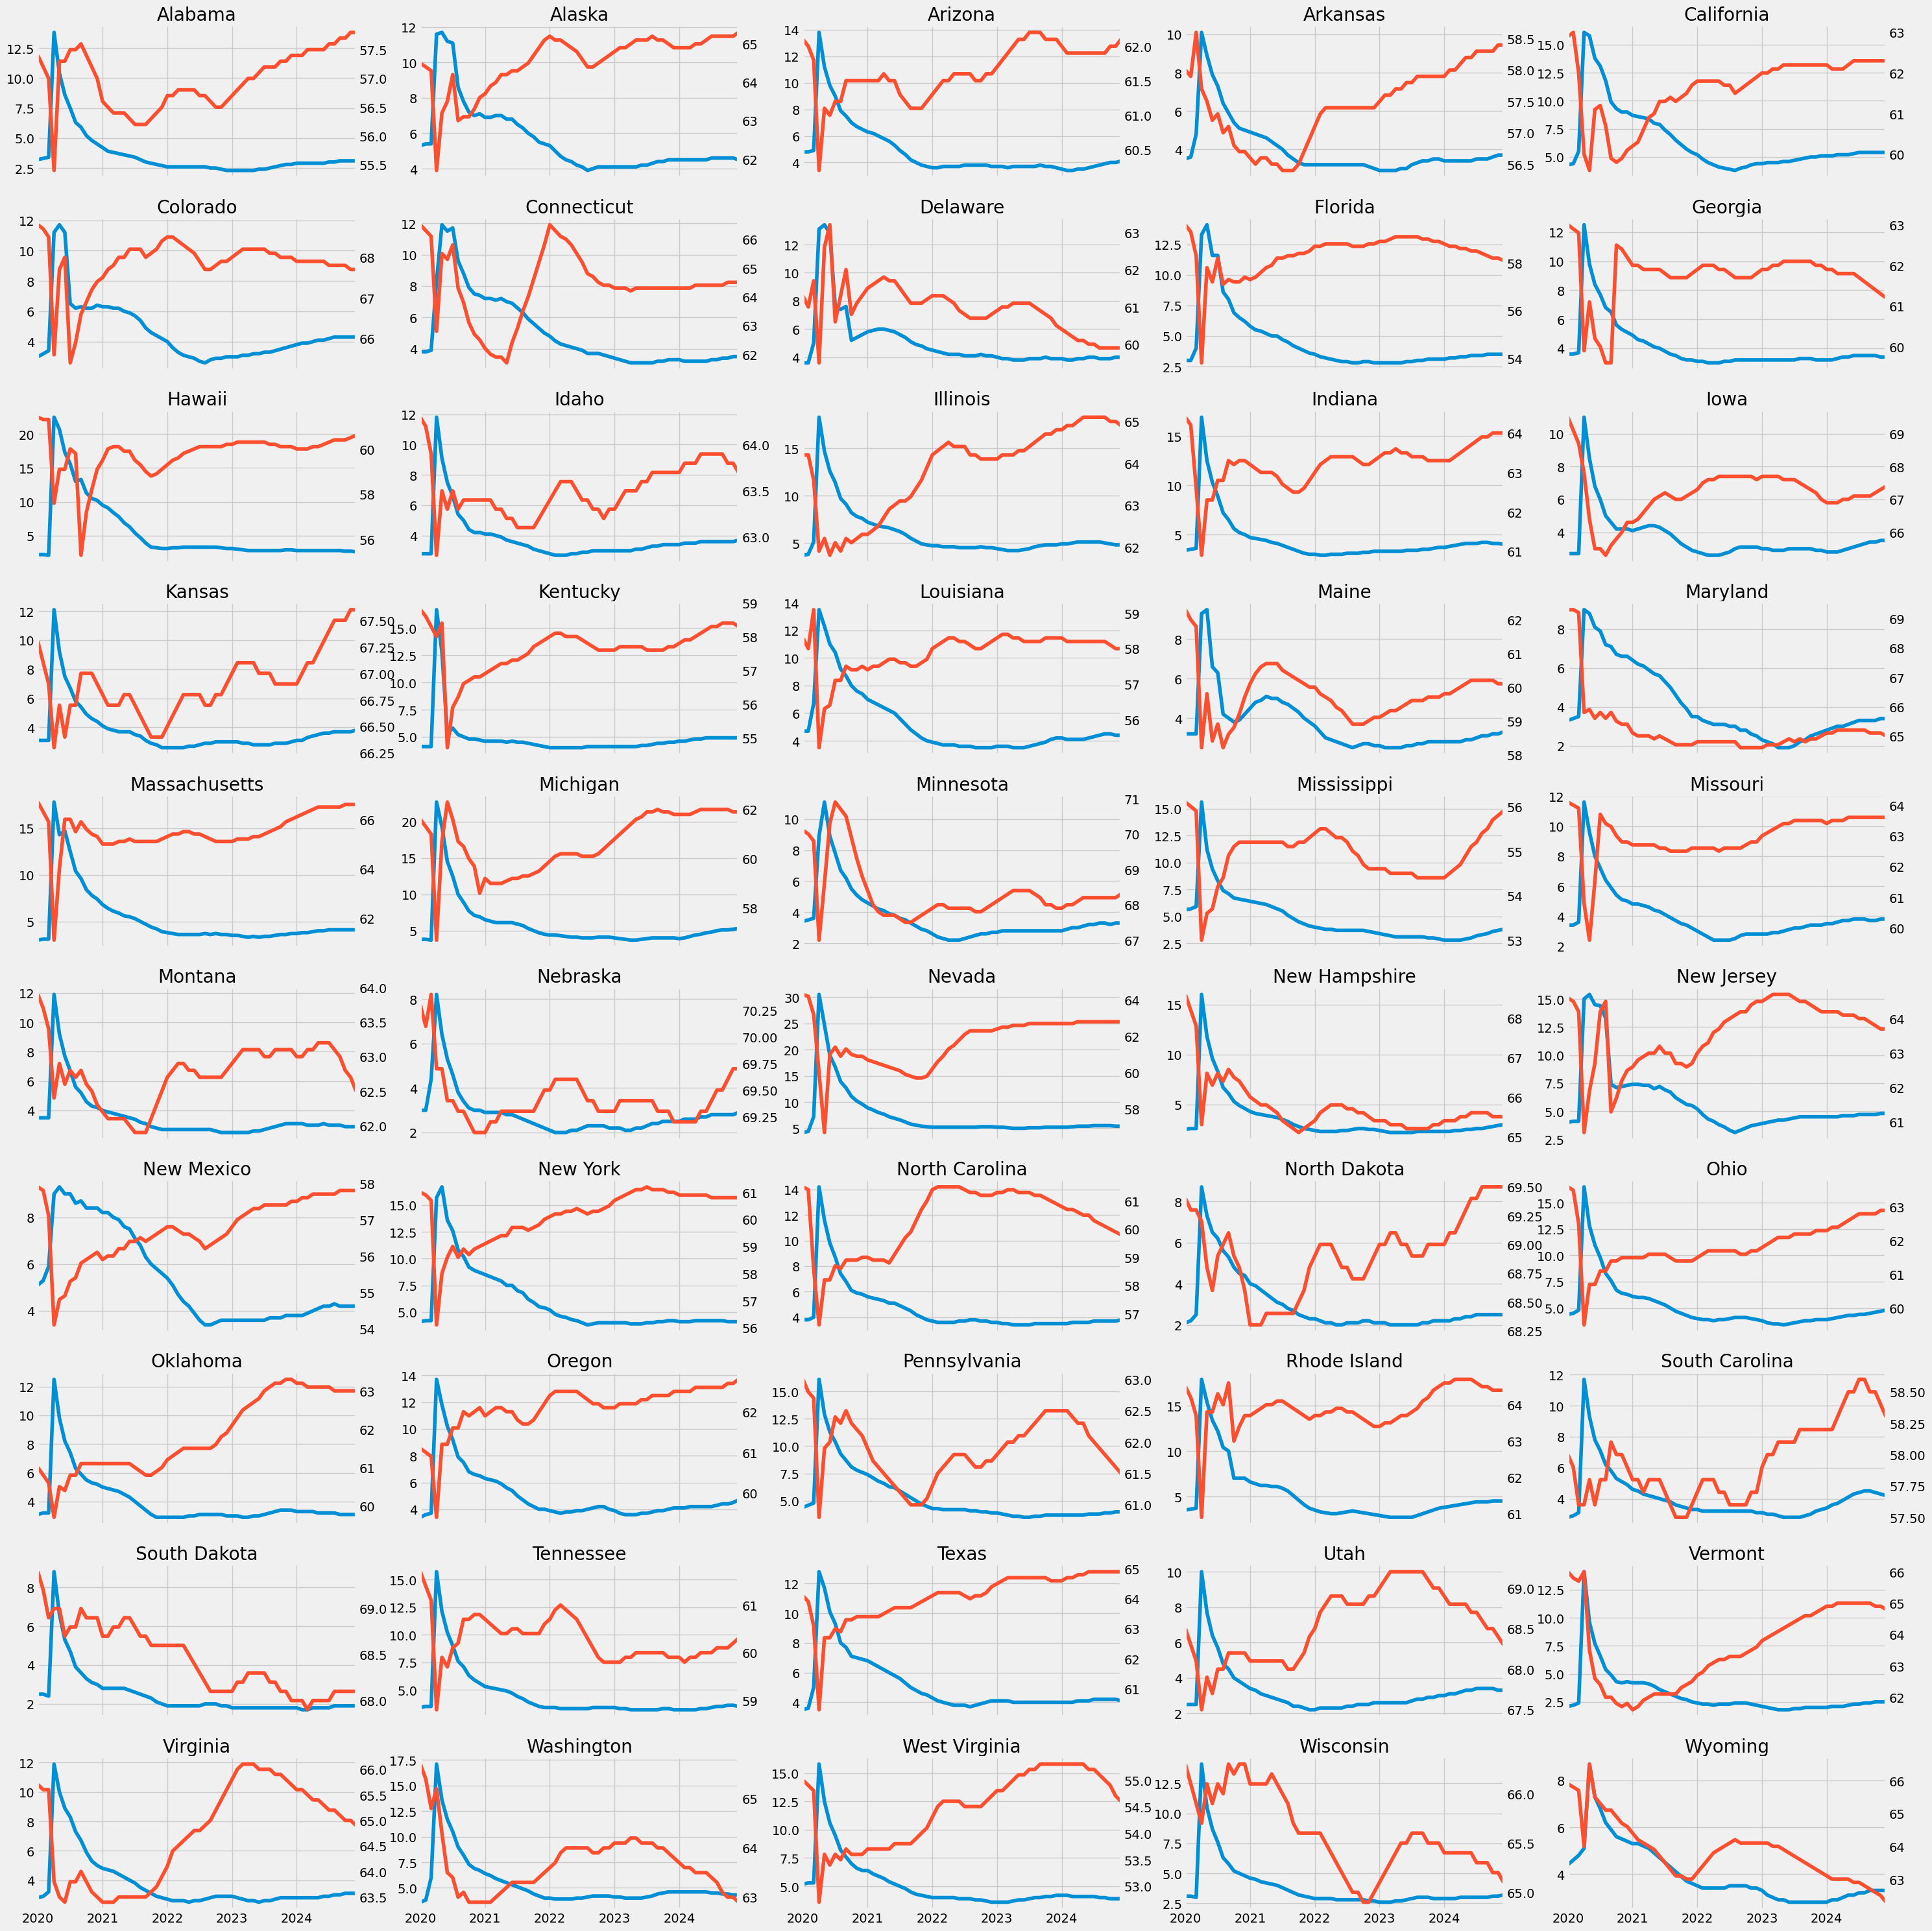

In [6]:
fig, axs = plt.subplots(10, 5, figsize=(30, 30), sharex=True)
axs = axs.flatten()

i = 0
for state in uemp_states.columns:
    if state == "District of Columbia":
        continue # DC doesn't have participation rate data, so it's skipped
    ax2 = axs[i].twinx()
    uemp_states.query('index >= 2020 and index < 2025')[state] \
        .plot(ax=axs[i], label='Unemployment')
    part_states.query('index >= 2020 and index < 2025')[state] \
        .plot(ax=ax2, label='Participation', color=color_pal[1])
    
    # All state graphs are shown in one image
    ax2.grid(False)
    axs[i].set_title(state)
    i += 1
plt.tight_layout()
plt.show()